Problem 1

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Diabetes Classifier Results:
Accuracy: 0.75
Precision: 0.61
Recall: 0.69
F1 Score: 0.65


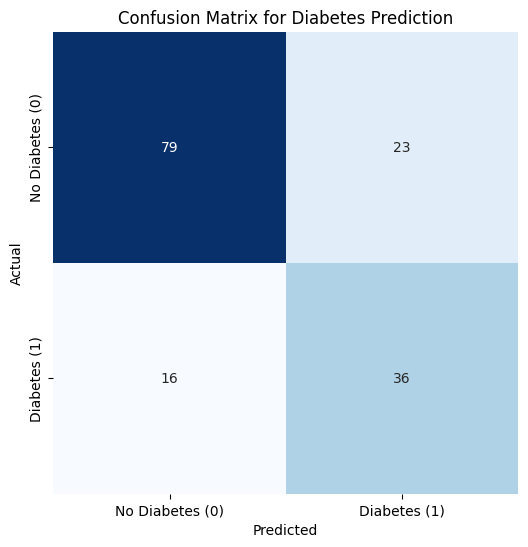

              precision    recall  f1-score   support

 No Diabetes       0.83      0.77      0.80       102
    Diabetes       0.61      0.69      0.65        52

    accuracy                           0.75       154
   macro avg       0.72      0.73      0.73       154
weighted avg       0.76      0.75      0.75       154



In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn import datasets
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import log_loss
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Import the necessary library for Google Colab drive mounting and import drive
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv('/content/drive/My Drive/diabetes.csv')

# Data Preprocessing

# Select features (Pregnancies, Glucose, BloodPressure, SkinThickness, Insulin, BMI, DiabetesPedigreeFunction, Age) and target (Outcome)
X_diabetes = df[['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']]
y_diabetes = df['Outcome']
names = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']

# Split the data into training and test sets (80-20 split)
X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(X_diabetes, y_diabetes, test_size=0.2, random_state=4)


scaler = StandardScaler()
# Standardize all the inputs
X_train_d[names] = scaler.fit_transform(X_train_d[names])
X_train_d.head()
X_test_d[names] = scaler.fit_transform(X_test_d[names])
X_test_d.head()


scaler2 = MinMaxScaler()
# Normalize all the inputs
X_train_d[names] = scaler2.fit_transform(X_train_d[names])
X_train_d.head()
X_test_d[names] = scaler2.fit_transform(X_test_d[names])
X_test_d.head()

# Create and train the logistic regression model
log_reg_d = LogisticRegression(max_iter=1000, class_weight='balanced')
log_reg_d.fit(X_train_d, y_train_d)

# Predict on the test set
y_pred_d = log_reg_d.predict(X_test_d)

# Calculate evaluation metrics: accuracy, precision, recall, and F1 score
accuracy_d = accuracy_score(y_test_d, y_pred_d)
precision_d = precision_score(y_test_d, y_pred_d)
recall_d = recall_score(y_test_d, y_pred_d)
f1_d = f1_score(y_test_d, y_pred_d)

# Print results
print(f"Diabetes Classifier Results:")
print(f"Accuracy: {accuracy_d:.2f}")
print(f"Precision: {precision_d:.2f}")
print(f"Recall: {recall_d:.2f}")
print(f"F1 Score: {f1_d:.2f}")

# Generate the confusion matrix
cm = confusion_matrix(y_test_d, y_pred_d)

# Plot confusion matrix using seaborn heatmap
plt.figure(figsize=(6,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=['No Diabetes (0)', 'Diabetes (1)'],
            yticklabels=['No Diabetes (0)', 'Diabetes (1)'])
plt.title('Confusion Matrix for Diabetes Prediction')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# Detailed classification report
from sklearn.metrics import classification_report
print(classification_report(y_test_d, y_pred_d, target_names=['No Diabetes', 'Diabetes']))



Problem 2: Cancer is from sklearn


Classification Report without penalty:
              precision    recall  f1-score   support

   malignant       0.95      0.88      0.91        42
      benign       0.93      0.97      0.95        72

    accuracy                           0.94       114
   macro avg       0.94      0.93      0.93       114
weighted avg       0.94      0.94      0.94       114


Classification Report with penalty:
              precision    recall  f1-score   support

   malignant       1.00      0.90      0.95        42
      benign       0.95      1.00      0.97        72

    accuracy                           0.96       114
   macro avg       0.97      0.95      0.96       114
weighted avg       0.97      0.96      0.96       114



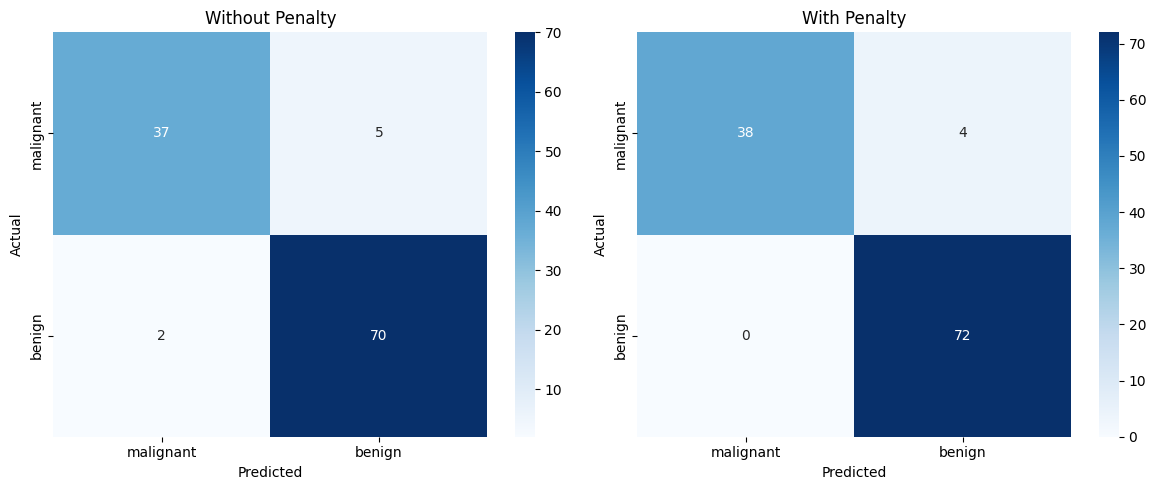

In [7]:
# Load the cancer dataset
cancer = datasets.load_breast_cancer()

# Create features and labels
X = cancer.data
y = cancer.target

# Split the dataset into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=82, stratify=y)

# Standardize the features (scaling the dataset)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Function to train logistic regression model and return results
def evaluate_logistic_regression(penalty=None):
    # Build the logistic regression model
    if penalty:
        log_reg = LogisticRegression(penalty='l2', C=0.10, max_iter=10000)
    else:
        log_reg = LogisticRegression(max_iter=10000)

    # Train the model
    log_reg.fit(X_train_scaled, y_train)

    # Make predictions
    y_pred = log_reg.predict(X_test_scaled)

    # Return the classification report and confusion matrix
    class_report = classification_report(y_test, y_pred, target_names=cancer.target_names)
    conf_matrix = confusion_matrix(y_test, y_pred)

    return class_report, conf_matrix

# Evaluate logistic regression without penalty
class_report_no_penalty, conf_matrix_no_penalty = evaluate_logistic_regression(penalty=None)

# Evaluate logistic regression with penalty
class_report_penalty, conf_matrix_penalty = evaluate_logistic_regression(penalty='l2')

# Print classification reports for comparison
print("Classification Report without penalty:")
print(class_report_no_penalty)
print("\nClassification Report with penalty:")
print(class_report_penalty)

# Plot both confusion matrices for comparison
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Confusion matrix without penalty
sns.heatmap(conf_matrix_no_penalty, annot=True, fmt='d', cmap='Blues', xticklabels=cancer.target_names, yticklabels=cancer.target_names, ax=ax[0])
ax[0].set_title("Without Penalty")
ax[0].set_xlabel("Predicted")
ax[0].set_ylabel("Actual")

# Confusion matrix with penalty
sns.heatmap(conf_matrix_penalty, annot=True, fmt='d', cmap='Blues', xticklabels=cancer.target_names, yticklabels=cancer.target_names, ax=ax[1])
ax[1].set_title("With Penalty")
ax[1].set_xlabel("Predicted")
ax[1].set_ylabel("Actual")

plt.tight_layout()
plt.show()



Problem 3

Classification Report:
               precision    recall  f1-score   support

   malignant       0.90      0.90      0.90        42
      benign       0.94      0.94      0.94        72

    accuracy                           0.93       114
   macro avg       0.92      0.92      0.92       114
weighted avg       0.93      0.93      0.93       114



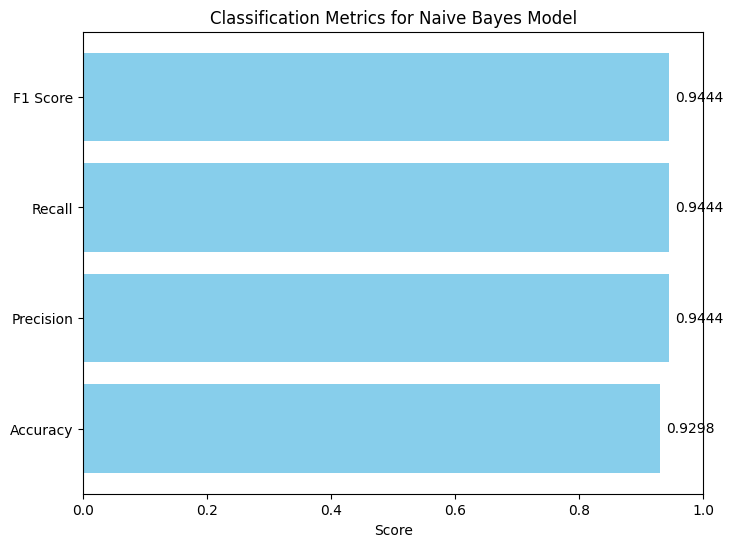

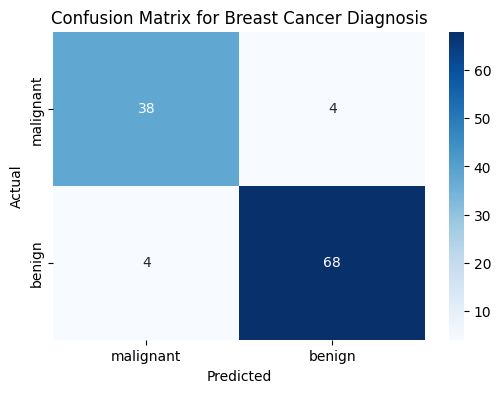

In [11]:
# Re-import necessary libraries + Gaussian Naive Bayes
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score

# Load the cancer dataset
from sklearn import datasets
cancer = datasets.load_breast_cancer()

# Create features and labels
X = cancer.data
y = cancer.target

# Split the dataset into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Standardize the features (optional for Naive Bayes, but can be helpful)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Build the Naive Bayes model
nb_model = GaussianNB()

# Train the model
nb_model.fit(X_train_scaled, y_train)

# Make predictions
y_pred = nb_model.predict(X_test_scaled)

# Calculate the evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Print classification report
print("Classification Report:\n", classification_report(y_test, y_pred, target_names=cancer.target_names))

# Plot the metrics (accuracy, precision, recall, F1 score)
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
values = [accuracy, precision, recall, f1]

# Create a bar plot for the metrics
plt.figure(figsize=(8, 6))
plt.barh(metrics, values, color='skyblue')
plt.xlim(0, 1)
for i, v in enumerate(values):
    plt.text(v + 0.01, i, f"{v:.4f}", va='center')
plt.title('Classification Metrics for Naive Bayes Model')
plt.xlabel('Score')
plt.show()

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)

# Plot Confusion Matrix as Heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=cancer.target_names, yticklabels=cancer.target_names)
plt.title('Confusion Matrix for Breast Cancer Diagnosis')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

For both malignant and benign cases, the metrics show that the Naive Bayes approach is less effective in classification than the the logistic regression model in earlier problems. This is likely caused by the assumption of conditional independence that is made in the Naive Bayes approach not being as accurate in practice.

Problem 4

Optimal number of principal components (K): 18
Metrics at Optimal K:
Accuracy: 0.9825
Precision: 0.9861
Recall: 0.9861
F1 Score: 0.9861


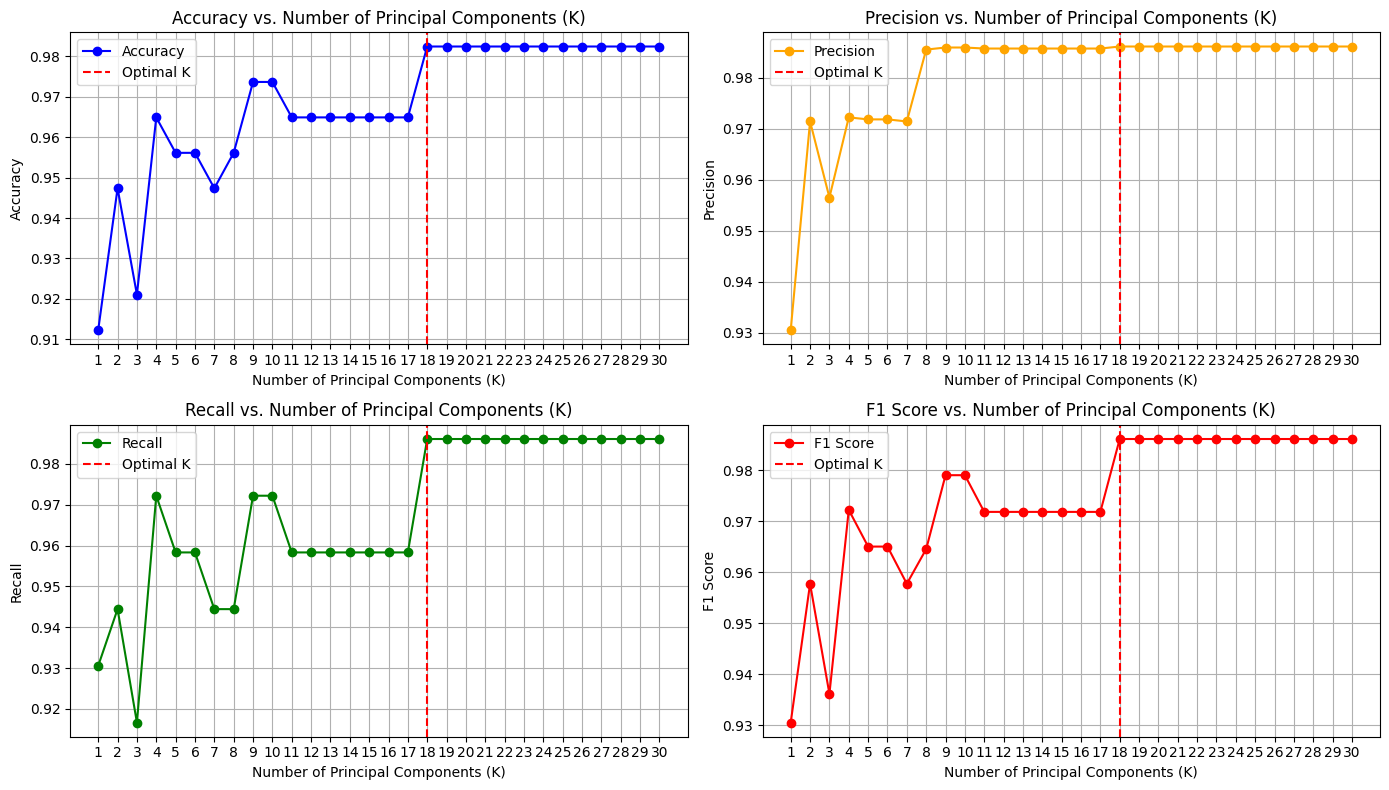

In [9]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Load the cancer dataset
cancer = datasets.load_breast_cancer()

# Create features and labels
X = cancer.data
y = cancer.target

# Split the dataset into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Variables to store results
results = {'K': [], 'Accuracy': [], 'Precision': [], 'Recall': [], 'F1 Score': []}

# Define maximum number of principal components to test
max_k = X_train.shape[1]  # Total features in original dataset (30)

# Iterate over different values of K
for k in range(1, max_k + 1):
    # Apply PCA
    pca = PCA(n_components=k)
    X_train_pca = pca.fit_transform(X_train_scaled)
    X_test_pca = pca.transform(X_test_scaled)

    # Train the Logistic Regression model
    model = LogisticRegression()
    model.fit(X_train_pca, y_train)

    # Make predictions
    y_pred = model.predict(X_test_pca)

    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    # Store the results
    results['K'].append(k)
    results['Accuracy'].append(accuracy)
    results['Precision'].append(precision)
    results['Recall'].append(recall)
    results['F1 Score'].append(f1)

# Convert results to a DataFrame for easier plotting
results_df = pd.DataFrame(results)

# Find the optimal K (based on maximum accuracy)
optimal_index = results_df['Accuracy'].idxmax()
optimal_k = results_df.loc[optimal_index, 'K']
optimal_accuracy = results_df.loc[optimal_index, 'Accuracy']
optimal_precision = results_df.loc[optimal_index, 'Precision']
optimal_recall = results_df.loc[optimal_index, 'Recall']
optimal_f1 = results_df.loc[optimal_index, 'F1 Score']

# Print optimal K and its metrics
print(f"Optimal number of principal components (K): {optimal_k}")
print(f"Metrics at Optimal K:")
print(f"Accuracy: {optimal_accuracy:.4f}")
print(f"Precision: {optimal_precision:.4f}")
print(f"Recall: {optimal_recall:.4f}")
print(f"F1 Score: {optimal_f1:.4f}")

# Plot the metrics
plt.figure(figsize=(14, 8))

# Plot accuracy
plt.subplot(2, 2, 1)
plt.plot(results_df['K'], results_df['Accuracy'], marker='o', label='Accuracy', color='blue')
plt.axvline(x=optimal_k, color='red', linestyle='--', label='Optimal K')
plt.title('Accuracy vs. Number of Principal Components (K)')
plt.xlabel('Number of Principal Components (K)')
plt.ylabel('Accuracy')
plt.xticks(results_df['K'])
plt.grid()
plt.legend()

# Plot precision
plt.subplot(2, 2, 2)
plt.plot(results_df['K'], results_df['Precision'], marker='o', label='Precision', color='orange')
plt.axvline(x=optimal_k, color='red', linestyle='--', label='Optimal K')
plt.title('Precision vs. Number of Principal Components (K)')
plt.xlabel('Number of Principal Components (K)')
plt.ylabel('Precision')
plt.xticks(results_df['K'])
plt.grid()
plt.legend()

# Plot recall
plt.subplot(2, 2, 3)
plt.plot(results_df['K'], results_df['Recall'], marker='o', label='Recall', color='green')
plt.axvline(x=optimal_k, color='red', linestyle='--', label='Optimal K')
plt.title('Recall vs. Number of Principal Components (K)')
plt.xlabel('Number of Principal Components (K)')
plt.ylabel('Recall')
plt.xticks(results_df['K'])
plt.grid()
plt.legend()

# Plot F1 Score
plt.subplot(2, 2, 4)
plt.plot(results_df['K'], results_df['F1 Score'], marker='o', label='F1 Score', color='red')
plt.axvline(x=optimal_k, color='red', linestyle='--', label='Optimal K')
plt.title('F1 Score vs. Number of Principal Components (K)')
plt.xlabel('Number of Principal Components (K)')
plt.ylabel('F1 Score')
plt.xticks(results_df['K'])
plt.grid()
plt.legend()

plt.tight_layout()
plt.show()


Overall metrics when using principal component analysis to find an optimum K were better than the previous attempts using all components, as several components (in this case 12) were found to not be as effective in the diagnosis of breast cancer.

Problem 5

Optimal number of principal components (K): 6
Metrics at Optimal K:
Accuracy: 0.9298
Precision: 0.9444
Recall: 0.9444
F1 Score: 0.9444


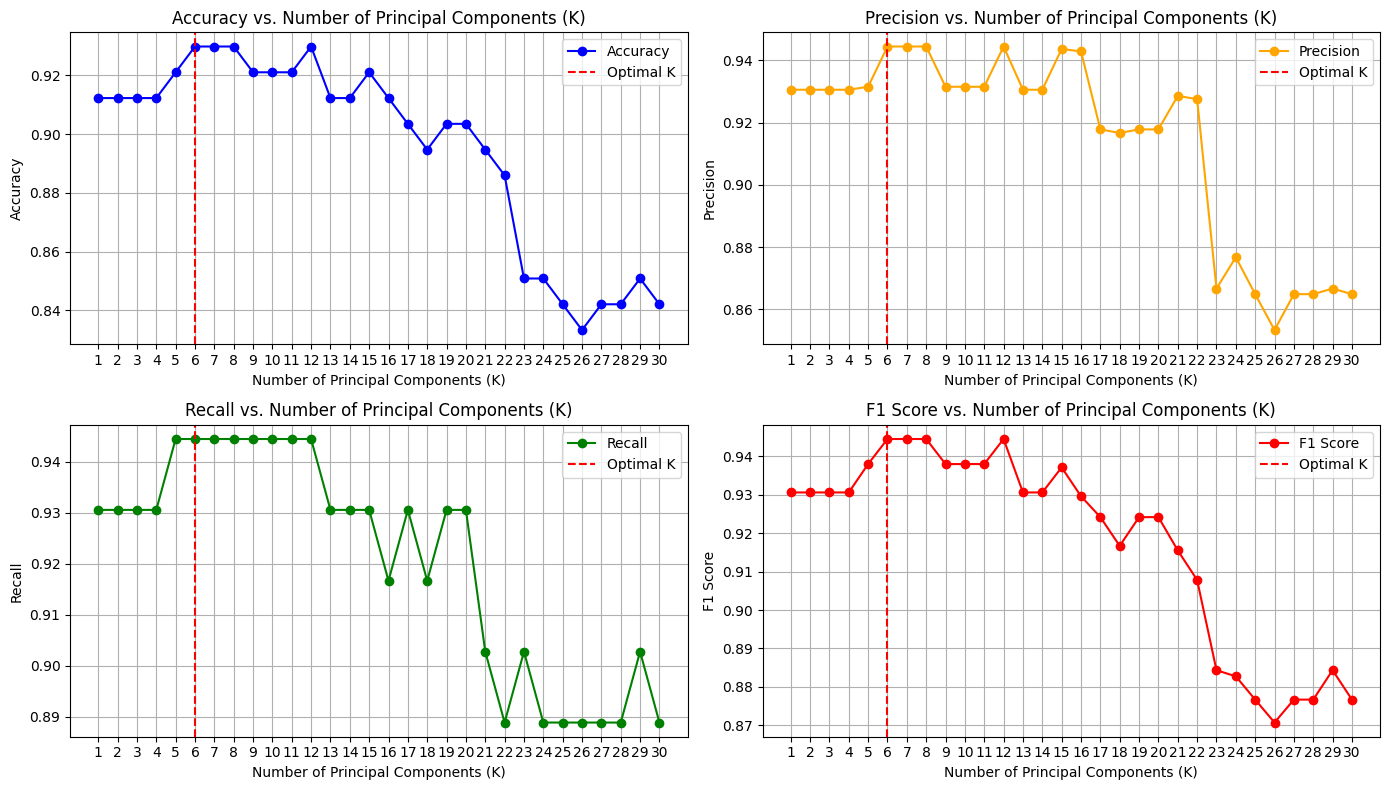

In [10]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Load the cancer dataset
cancer = datasets.load_breast_cancer()

# Create features and labels
X = cancer.data
y = cancer.target

# Split the dataset into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Variables to store results
results = {'K': [], 'Accuracy': [], 'Precision': [], 'Recall': [], 'F1 Score': []}

# Define maximum number of principal components to test
max_k = X_train.shape[1]  # Total features in original dataset (30)

# Iterate over different values of K
for k in range(1, max_k + 1):
    # Apply PCA
    pca = PCA(n_components=k)
    X_train_pca = pca.fit_transform(X_train_scaled)
    X_test_pca = pca.transform(X_test_scaled)

    # Train the Naive Bayes model
    model = GaussianNB()
    model.fit(X_train_pca, y_train)

    # Make predictions
    y_pred = model.predict(X_test_pca)

    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    # Store the results
    results['K'].append(k)
    results['Accuracy'].append(accuracy)
    results['Precision'].append(precision)
    results['Recall'].append(recall)
    results['F1 Score'].append(f1)

# Convert results to a DataFrame for easier plotting
results_df = pd.DataFrame(results)

# Find the optimal K (based on maximum accuracy)
optimal_index = results_df['Accuracy'].idxmax()
optimal_k = results_df.loc[optimal_index, 'K']
optimal_accuracy = results_df.loc[optimal_index, 'Accuracy']
optimal_precision = results_df.loc[optimal_index, 'Precision']
optimal_recall = results_df.loc[optimal_index, 'Recall']
optimal_f1 = results_df.loc[optimal_index, 'F1 Score']

# Print optimal K and its metrics
print(f"Optimal number of principal components (K): {optimal_k}")
print(f"Metrics at Optimal K:")
print(f"Accuracy: {optimal_accuracy:.4f}")
print(f"Precision: {optimal_precision:.4f}")
print(f"Recall: {optimal_recall:.4f}")
print(f"F1 Score: {optimal_f1:.4f}")

# Plot the metrics
plt.figure(figsize=(14, 8))

# Plot accuracy
plt.subplot(2, 2, 1)
plt.plot(results_df['K'], results_df['Accuracy'], marker='o', label='Accuracy', color='blue')
plt.axvline(x=optimal_k, color='red', linestyle='--', label='Optimal K')
plt.title('Accuracy vs. Number of Principal Components (K)')
plt.xlabel('Number of Principal Components (K)')
plt.ylabel('Accuracy')
plt.xticks(results_df['K'])
plt.grid()
plt.legend()

# Plot precision
plt.subplot(2, 2, 2)
plt.plot(results_df['K'], results_df['Precision'], marker='o', label='Precision', color='orange')
plt.axvline(x=optimal_k, color='red', linestyle='--', label='Optimal K')
plt.title('Precision vs. Number of Principal Components (K)')
plt.xlabel('Number of Principal Components (K)')
plt.ylabel('Precision')
plt.xticks(results_df['K'])
plt.grid()
plt.legend()

# Plot recall
plt.subplot(2, 2, 3)
plt.plot(results_df['K'], results_df['Recall'], marker='o', label='Recall', color='green')
plt.axvline(x=optimal_k, color='red', linestyle='--', label='Optimal K')
plt.title('Recall vs. Number of Principal Components (K)')
plt.xlabel('Number of Principal Components (K)')
plt.ylabel('Recall')
plt.xticks(results_df['K'])
plt.grid()
plt.legend()

# Plot F1 Score
plt.subplot(2, 2, 4)
plt.plot(results_df['K'], results_df['F1 Score'], marker='o', label='F1 Score', color='red')
plt.axvline(x=optimal_k, color='red', linestyle='--', label='Optimal K')
plt.title('F1 Score vs. Number of Principal Components (K)')
plt.xlabel('Number of Principal Components (K)')
plt.ylabel('F1 Score')
plt.xticks(results_df['K'])
plt.grid()
plt.legend()

plt.tight_layout()
plt.show()


Using the Naive Bayes approach with principal component analysis yielded an F1 score better than the Naive Bayes approach without PCA, but worse than all others using logistic regression. With this info we can conclude that conditional independence should not be assumed with breast cancer for the most acccurate results.